# Shortpick v3 买入后价格路径与卖出时点复盘

## tl;dr

- 历史上并不是“通常买入后就跌”：候选 R15 的次日收盘低于买入价占 **49.6%**，与五五开接近；第 20 个交易日仍低于买入价占 **38.3%**。
- 但持仓过程中出现浮亏很常见：**82.0%** 的买入在随后 20 个交易日内至少有一次收盘低于买入价，20 日内最差收盘收益的中位数为 **-3.2%**。
- 策略通常不是短线止损：候选 R15 的 **96.8%** 卖出由 20 个交易日到期触发；卖出事件盈利占 **57.8%**，净收益中位数 **+1.71%**。
- 最近体感确实偏差：截至行情 **2026-07-16**，4 个已有次日价格的独立纸面买点中 3 个仍亏损，且 2 个次日跌幅超过 5%；历史次日跌超 5% 仅约 **5.0%**。
- 最近 4 笔截至最新收盘的等权平均收益为约 **-2.04%**，同期沪深 300 从各自入场日到最新日的等权平均约 **-1.31%**。主要异常来自电科网安，而不是每一笔都显著跑输市场。

## Context & Methods

### Key Assumptions

- 历史样本使用当前 R14/R15 研究共用的确定性执行快照，区间为 2023-09 至 2026-06；所有策略在同一候选、行情、费用与 100 股一手约束下重放。
- “第 N 日收益”以实际策略买入收盘价为基准，观察其后第 N 个有行情的交易日收盘价，不含卖出费用；“卖出收益”直接采用回放 ledger 的含买卖费用收益。
- “最近买点”按股票与实际买入日去重，避免三个策略同时买入同一只股票被重复计数。
- 最近数据只截至本地数据库已有的 2026-07-16 收盘；2026-07-17 尚无日线，不能把当日盘中体感混入收盘统计。

## Data

In [1]:
from __future__ import annotations

from collections import Counter
from datetime import date
from pathlib import Path
import gzip
import json
import sqlite3
import statistics
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from ashare_evidence.rolling_tranche_account_replay import (
    build_shortpick_v3_rolling_account_replay_artifact,
)
from ashare_evidence.rolling_tranche_execution_contract import (
    build_shortpick_v3_rolling_tranche_execution_contract,
)

RUNTIME_ROOT = Path("/Users/hernando_zhao/codex/runtime/projects/ashare-dashboard")
SNAPSHOT_PATH = (
    RUNTIME_ROOT
    / "data/artifacts/research_validation/rolling_account_execution_snapshots"
    / "shortpick-v3-execution-snapshot-067c5b83e085f95f.json.gz"
)
PAPER_STATE_PATH = RUNTIME_ROOT / "data/shortpick-strategy-lab-paper-state.json"
MARKET_DB_PATH = RUNTIME_ROOT / "data/ashare_hot.db"
SUMMARY_OUTPUT = ROOT / "output/shortpick-v3-post-entry-analysis-20260717.json"
ANALYSIS_DB = ROOT / "output/shortpick-v3-post-entry-analysis-20260717.db"

STRATEGY_LABELS = {
    "daily_14_tranche_rank_weighted_compound_min2250_layered_rank1_quickfail_rank3_pullback_exit_v1":
        "主策略 R14",
    "daily_14_tranche_upstream_meta_signal_quality_min2250_weak100_strong165_lead135_low090_v1":
        "上游稳健 R14",
    "daily_15_tranche_rank_adjusted_r5_093_strong154_replacement_top5_gap010_fill075_market_cap25_v1":
        "候选 R15",
}
HORIZONS = [1, 3, 5, 10, 20]

with gzip.open(SNAPSHOT_PATH, "rt", encoding="utf-8") as handle:
    execution_snapshot = json.load(handle)
paper_state = json.loads(PAPER_STATE_PATH.read_text(encoding="utf-8"))

contract = build_shortpick_v3_rolling_tranche_execution_contract(
    model_spec_id="negative_month_rank_weight_adjusted_capacity_cluster_v3_top3_20d_v1"
)
active_configs = [
    row
    for row in contract["candidate_configurations"]
    if row["config_id"] in STRATEGY_LABELS
]

replay = build_shortpick_v3_rolling_account_replay_artifact(
    candidate_run=execution_snapshot["inputs"]["candidate_run"],
    trial_id=execution_snapshot["trial_id"],
    market_bars_by_symbol=execution_snapshot["inputs"]["market_bars_by_symbol"],
    initial_cash_cny=execution_snapshot["inputs"]["account_profile"]["initial_cash_cny"],
    buy_cost_bps=execution_snapshot["inputs"]["account_profile"]["buy_cost_bps"],
    sell_cost_bps=execution_snapshot["inputs"]["account_profile"]["sell_cost_bps"],
    min_order_notional_cny=execution_snapshot["inputs"]["account_profile"]["min_order_notional_cny"],
    max_entry_lag_days=execution_snapshot["inputs"]["account_profile"]["max_entry_lag_days"],
    candidate_inventory_rows=execution_snapshot["inputs"]["candidate_inventory_rows"],
    candidate_configurations=active_configs,
)

bars_by_symbol = {
    symbol: [(row["day"], float(row["close"])) for row in rows]
    for symbol, rows in execution_snapshot["inputs"]["market_bars_by_symbol"].items()
}

print("execution snapshot:", execution_snapshot["artifact_id"])
print("paper state generated_at:", paper_state["generated_at"])
print("paper source coverage:", paper_state["source_coverage"])

execution snapshot: shortpick-v3-execution-snapshot-067c5b83e085f95f
paper state generated_at: 2026-07-16T08:49:42.080568+00:00
paper source coverage: {'common_start_enforced': True, 'end_date': '2026-07-16', 'source_count': 7, 'start_date': '2026-07-08', 'strategy_count': 3}


### Validate source grain and deterministic replay

In [2]:
assert replay["status"] == "completed"
assert len(replay["results"]) == 3

candidate_r15 = next(
    row for row in replay["results"]
    if STRATEGY_LABELS[row["config_id"]] == "候选 R15"
)
assert candidate_r15["summary"] == execution_snapshot["baseline_output"]["summary"]
assert candidate_r15["order_ledger"] == execution_snapshot["baseline_output"]["order_ledger"]

latest_market_date = None
with sqlite3.connect(f"file:{MARKET_DB_PATH}?mode=ro", uri=True) as connection:
    latest_market_date = connection.execute(
        "SELECT MAX(date(observed_at)) FROM market_bars WHERE timeframe = '1d'"
    ).fetchone()[0]

assert latest_market_date == paper_state["source_coverage"]["end_date"] == "2026-07-16"
print("deterministic R15 replay matched snapshot; latest market date:", latest_market_date)

deterministic R15 replay matched snapshot; latest market date: 2026-07-16


## Results

### Historical post-entry path

In [3]:
historical_rows = []
strategy_rows = []
exit_reason_rows = []

for result in replay["results"]:
    strategy_id = result["config_id"]
    strategy_label = STRATEGY_LABELS[strategy_id]
    ledger = result["order_ledger"]
    buys = [row for row in ledger if row["action"] == "buy"]
    sells = [row for row in ledger if row["action"] == "sell"]

    sell_returns = [float(row["return"]) for row in sells]
    sell_reasons = Counter(row["reason"] for row in sells)
    strategy_rows.append(
        {
            "strategy": strategy_label,
            "buy_orders": len(buys),
            "sell_events": len(sells),
            "sell_win_rate": sum(value > 0 for value in sell_returns) / len(sell_returns),
            "median_sell_return": statistics.median(sell_returns),
            "mechanical_exit_share": sell_reasons["mechanical_horizon"] / len(sells),
            "total_return": result["summary"]["total_return"],
            "max_drawdown": result["summary"]["max_drawdown"],
        }
    )
    for reason, count in sell_reasons.items():
        exit_reason_rows.append(
            {
                "strategy": strategy_label,
                "exit_reason": reason,
                "count": count,
                "share": count / len(sells),
            }
        )

    for horizon in HORIZONS:
        horizon_returns = []
        worst_closes = []
        best_closes = []
        for buy in buys:
            series = bars_by_symbol.get(buy["symbol"], [])
            dates = [day for day, _ in series]
            if buy["trade_day"] not in dates:
                continue
            entry_index = dates.index(buy["trade_day"])
            if entry_index + horizon >= len(series):
                continue
            forward = [
                close / float(buy["price"]) - 1
                for _, close in series[entry_index + 1 : entry_index + horizon + 1]
            ]
            horizon_returns.append(forward[-1])
            worst_closes.append(min(forward))
            best_closes.append(max(forward))
        historical_rows.append(
            {
                "strategy": strategy_label,
                "horizon_days": horizon,
                "sample_size": len(horizon_returns),
                "negative_rate": sum(value < 0 for value in horizon_returns) / len(horizon_returns),
                "mean_return": statistics.mean(horizon_returns),
                "median_return": statistics.median(horizon_returns),
                "ever_below_entry_rate": sum(value < 0 for value in worst_closes) / len(worst_closes),
                "median_worst_close_return": statistics.median(worst_closes),
                "ever_above_entry_rate": sum(value > 0 for value in best_closes) / len(best_closes),
            }
        )

historical_path = pd.DataFrame(historical_rows)
strategy_summary = pd.DataFrame(strategy_rows)
exit_reasons = pd.DataFrame(exit_reason_rows)

display(
    historical_path.assign(
        negative_rate=lambda frame: frame["negative_rate"].map(lambda value: f"{value:.1%}"),
        median_return=lambda frame: frame["median_return"].map(lambda value: f"{value:+.2%}"),
        ever_below_entry_rate=lambda frame: frame["ever_below_entry_rate"].map(lambda value: f"{value:.1%}"),
        median_worst_close_return=lambda frame: frame["median_worst_close_return"].map(
            lambda value: f"{value:+.2%}"
        ),
    )
)
display(
    strategy_summary.assign(
        sell_win_rate=lambda frame: frame["sell_win_rate"].map(lambda value: f"{value:.1%}"),
        median_sell_return=lambda frame: frame["median_sell_return"].map(lambda value: f"{value:+.2%}"),
        mechanical_exit_share=lambda frame: frame["mechanical_exit_share"].map(lambda value: f"{value:.1%}"),
        total_return=lambda frame: frame["total_return"].map(lambda value: f"{value:+.1%}"),
        max_drawdown=lambda frame: frame["max_drawdown"].map(lambda value: f"{value:+.1%}"),
    )
)

,strategy,horizon_days,sample_size,negative_rate,mean_return,median_return,ever_below_entry_rate,median_worst_close_return,ever_above_entry_rate
0,主策略 R14,1,649,50.2%,0.000550,-0.03%,50.2%,-0.03%,0.462250
1,主策略 R14,3,647,50.2%,0.005393,-0.05%,67.2%,-1.18%,0.658423
2,主策略 R14,5,643,49.3%,0.012621,+0.00%,73.9%,-1.78%,0.724728
3,主策略 R14,10,637,42.2%,0.027051,+0.93%,78.6%,-2.71%,0.819466
4,主策略 R14,20,622,37.1%,0.069429,+2.58%,82.5%,-3.47%,0.885852
5,上游稳健 R14,1,649,50.2%,0.000550,-0.03%,50.2%,-0.03%,0.462250
6,上游稳健 R14,3,647,50.2%,0.005393,-0.05%,67.2%,-1.18%,0.658423
7,上游稳健 R14,5,643,49.3%,0.012621,+0.00%,73.9%,-1.78%,0.724728
8,上游稳健 R14,10,637,42.2%,0.027051,+0.93%,78.6%,-2.71%,0.819466
9,上游稳健 R14,20,622,37.1%,0.069429,+2.58%,82.5%,-3.47%,0.885852


,strategy,buy_orders,sell_events,sell_win_rate,median_sell_return,mechanical_exit_share,total_return,max_drawdown
0,主策略 R14,651,625,59.0%,+2.03%,96.6%,+312.2%,-7.8%
1,上游稳健 R14,651,625,59.0%,+2.03%,96.6%,+312.2%,-7.8%
2,候选 R15,818,793,57.8%,+1.71%,96.8%,+332.1%,-6.9%


### Historical loss depth and recovery

In [4]:
r15_buys = [row for row in candidate_r15["order_ledger"] if row["action"] == "buy"]
r15_sells = {
    (row["signal_day"], row["symbol"], row["rank"]): row
    for row in candidate_r15["order_ledger"]
    if row["action"] == "sell" and row["reason"] != "market_value_concentration_rebalance"
}

r15_paths = []
for buy in r15_buys:
    series = bars_by_symbol[buy["symbol"]]
    dates = [day for day, _ in series]
    if buy["trade_day"] not in dates:
        continue
    entry_index = dates.index(buy["trade_day"])
    forward = [
        close / float(buy["price"]) - 1
        for _, close in series[entry_index + 1 : entry_index + 21]
    ]
    sell = r15_sells.get((buy["signal_day"], buy["symbol"], buy["rank"]))
    r15_paths.append({"buy": buy, "forward": forward, "sell": sell})

day1_returns = [row["forward"][0] for row in r15_paths if len(row["forward"]) >= 1]
day1_loss_over_5_rate = sum(value <= -0.05 for value in day1_returns) / len(day1_returns)

day1_losers = [
    row
    for row in r15_paths
    if len(row["forward"]) >= 20 and row["forward"][0] < 0 and row["sell"] is not None
]
day1_loser_exit_win_rate = (
    sum(row["sell"]["return"] > 0 for row in day1_losers) / len(day1_losers)
)

first5_below = [
    row
    for row in r15_paths
    if len(row["forward"]) >= 5 and min(row["forward"][:5]) < 0 and row["sell"] is not None
]
first5_below_exit_win_rate = (
    sum(row["sell"]["return"] > 0 for row in first5_below) / len(first5_below)
)

depth_rows = []
for horizon in [3, 5, 10, 20]:
    worst = [
        min(row["forward"][:horizon])
        for row in r15_paths
        if len(row["forward"]) >= horizon
    ]
    depth_rows.append(
        {
            "horizon_days": horizon,
            "sample_size": len(worst),
            "below_2pct_rate": sum(value <= -0.02 for value in worst) / len(worst),
            "below_5pct_rate": sum(value <= -0.05 for value in worst) / len(worst),
            "below_8pct_rate": sum(value <= -0.08 for value in worst) / len(worst),
            "median_worst_close_return": statistics.median(worst),
        }
    )

loss_depth = pd.DataFrame(depth_rows)
display(
    loss_depth.assign(
        **{
            column: loss_depth[column].map(lambda value: f"{value:.1%}")
            for column in [
                "below_2pct_rate",
                "below_5pct_rate",
                "below_8pct_rate",
                "median_worst_close_return",
            ]
        }
    )
)
print("历史次日跌超 5% 占比:", f"{day1_loss_over_5_rate:.1%}")
print("次日下跌后最终卖出盈利占比:", f"{day1_loser_exit_win_rate:.1%}")
print("前 5 日曾跌破成本后最终卖出盈利占比:", f"{first5_below_exit_win_rate:.1%}")

,horizon_days,sample_size,below_2pct_rate,below_5pct_rate,below_8pct_rate,median_worst_close_return
0,3,813,37.1%,13.7%,6.6%,-1.1%
1,5,808,44.9%,18.8%,10.3%,-1.7%
2,10,802,53.7%,29.4%,16.5%,-2.4%
3,20,788,60.9%,37.7%,23.5%,-3.2%


历史次日跌超 5% 占比: 5.0%
次日下跌后最终卖出盈利占比: 47.7%
前 5 日曾跌破成本后最终卖出盈利占比: 49.6%


### Recent paper entries versus CSI 300

In [5]:
unique_entries = {}
for record in paper_state["records"]:
    if record["action"] == "buy":
        unique_entries[(record["trade_date"], record["symbol"])] = record

recent_rows = []
with sqlite3.connect(f"file:{MARKET_DB_PATH}?mode=ro", uri=True) as connection:
    benchmark_rows = connection.execute(
        '''
        SELECT date(m.observed_at), m.close_price
        FROM market_bars AS m
        JOIN stocks AS s ON s.id = m.stock_id
        WHERE s.symbol = '000300.SH'
          AND m.timeframe = '1d'
          AND date(m.observed_at) >= '2026-07-08'
        ORDER BY date(m.observed_at), m.id
        '''
    ).fetchall()
    benchmark_close = {day: float(close) for day, close in benchmark_rows}

    for (entry_day, symbol), record in sorted(unique_entries.items()):
        price_rows = connection.execute(
            '''
            SELECT date(m.observed_at), m.close_price
            FROM market_bars AS m
            JOIN stocks AS s ON s.id = m.stock_id
            WHERE s.symbol = ?
              AND m.timeframe = '1d'
              AND date(m.observed_at) >= ?
            ORDER BY date(m.observed_at), m.id
            ''',
            (symbol, entry_day),
        ).fetchall()
        price_by_day = {day: float(close) for day, close in price_rows}
        ordered_prices = sorted(price_by_day.items())
        future_prices = [(day, close) for day, close in ordered_prices if day > entry_day]
        entry_price = float(record["price_cny"])
        latest_day, latest_close = ordered_prices[-1]
        benchmark_return = (
            benchmark_close[latest_day] / benchmark_close[entry_day] - 1
            if latest_day > entry_day
            else 0.0
        )
        latest_return = latest_close / entry_price - 1
        recent_rows.append(
            {
                "entry_date": entry_day,
                "symbol": symbol,
                "name": record["name"],
                "entry_price": entry_price,
                "observed_days": len(future_prices),
                "day1_return": (
                    future_prices[0][1] / entry_price - 1 if future_prices else None
                ),
                "latest_date": latest_day,
                "latest_close": latest_close,
                "latest_return": latest_return,
                "benchmark_return": benchmark_return,
                "excess_return": latest_return - benchmark_return,
            }
        )

recent_entries = pd.DataFrame(recent_rows)
observable_recent = recent_entries[recent_entries["observed_days"] > 0].copy()

display(
    recent_entries.assign(
        day1_return=lambda frame: frame["day1_return"].map(
            lambda value: "待观察" if pd.isna(value) else f"{value:+.2%}"
        ),
        latest_return=lambda frame: frame["latest_return"].map(lambda value: f"{value:+.2%}"),
        benchmark_return=lambda frame: frame["benchmark_return"].map(lambda value: f"{value:+.2%}"),
        excess_return=lambda frame: frame["excess_return"].map(lambda value: f"{value:+.2%}"),
    )
)

recent_negative_rate = (
    (observable_recent["latest_return"] < 0).sum() / len(observable_recent)
)
recent_day1_over_5_count = (observable_recent["day1_return"] <= -0.05).sum()
recent_equal_weight_return = observable_recent["latest_return"].mean()
recent_benchmark_return = observable_recent["benchmark_return"].mean()
recent_equal_weight_excess = observable_recent["excess_return"].mean()

print("可观察独立买点:", len(observable_recent))
print("当前仍低于成本:", f"{recent_negative_rate:.1%}")
print("次日跌超 5%:", f"{recent_day1_over_5_count}/{len(observable_recent)}")
print("股票等权平均:", f"{recent_equal_weight_return:+.2%}")
print("同期沪深300等权平均:", f"{recent_benchmark_return:+.2%}")
print("等权超额:", f"{recent_equal_weight_excess:+.2%}")

,entry_date,symbol,name,entry_price,observed_days,day1_return,latest_date,latest_close,latest_return,benchmark_return,excess_return
0,2026-07-10,002268.SZ,电科网安,15.34,4,-6.65%,2026-07-16,14.16,-7.69%,-1.72%,-5.97%
1,2026-07-10,003033.SZ,征和工业,70.21,4,-5.13%,2026-07-16,68.85,-1.94%,-1.72%,-0.21%
2,2026-07-13,601228.SH,广州港,2.96,3,+1.35%,2026-07-16,3.01,+1.69%,+0.06%,+1.62%
3,2026-07-15,002841.SZ,视源股份,48.19,1,-0.21%,2026-07-16,48.09,-0.21%,-1.85%,+1.64%
4,2026-07-16,603087.SH,甘李药业,69.40,0,待观察,2026-07-16,69.40,+0.00%,+0.00%,+0.00%


可观察独立买点: 4
当前仍低于成本: 75.0%
次日跌超 5%: 2/4
股票等权平均: -2.04%
同期沪深300等权平均: -1.31%
等权超额: -0.73%


### Visual comparison

/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_65347/709519075.py:34: UserWarning: Glyph 20080 (\N{CJK UNIFIED IDEOGRAPH-4E70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_65347/709519075.py:34: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_65347/709519075.py:34: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_65347/709519075.py:34: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_65347/709519075.py:34: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96

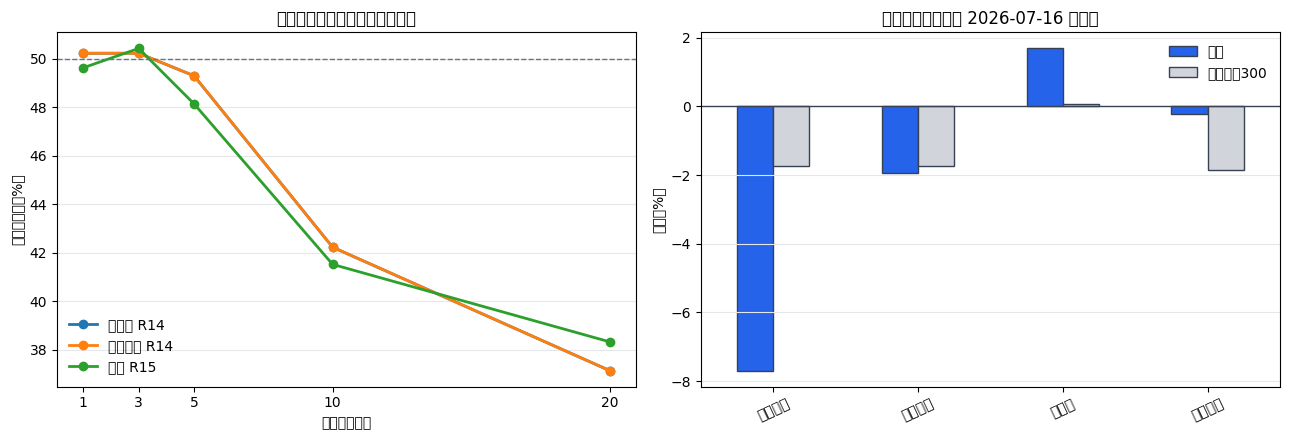

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for strategy, group in historical_path.groupby("strategy", sort=False):
    axes[0].plot(
        group["horizon_days"],
        group["negative_rate"] * 100,
        marker="o",
        linewidth=2,
        label=strategy,
    )
axes[0].axhline(50, color="#6B7280", linestyle="--", linewidth=1)
axes[0].set_title("历史买入后仍低于成本价的比例")
axes[0].set_xlabel("买入后交易日")
axes[0].set_ylabel("低于买入价（%）")
axes[0].set_xticks(HORIZONS)
axes[0].grid(axis="y", color="#E5E7EB")
axes[0].legend(frameon=False)

plot_recent = observable_recent.set_index("name")[["latest_return", "benchmark_return"]] * 100
plot_recent.columns = ["股票", "同期沪深300"]
plot_recent.plot.bar(
    ax=axes[1],
    color=["#2563EB", "#D1D5DB"],
    edgecolor="#374151",
)
axes[1].axhline(0, color="#374151", linewidth=1)
axes[1].set_title("最近独立买点截至 2026-07-16 的收益")
axes[1].set_xlabel("")
axes[1].set_ylabel("收益（%）")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", color="#E5E7EB")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Takeaways

In [7]:
candidate_row = strategy_summary[strategy_summary["strategy"] == "候选 R15"].iloc[0]
r15_day20 = historical_path[
    (historical_path["strategy"] == "候选 R15")
    & (historical_path["horizon_days"] == 20)
].iloc[0]

print(
    f"1. 买入次日下跌并非策略常态：历史为 "
    f"{historical_path[(historical_path.strategy == '候选 R15') & (historical_path.horizon_days == 1)].iloc[0].negative_rate:.1%}。"
)
print(
    f"2. 但持仓内浮亏是常态：20 日内曾跌破成本的比例为 "
    f"{r15_day20.ever_below_entry_rate:.1%}，最差收盘中位数为 "
    f"{r15_day20.median_worst_close_return:+.2%}。"
)
print(
    f"3. 卖出以 20 日到期为主（{candidate_row.mechanical_exit_share:.1%}）；"
    f"卖出盈利占比 {candidate_row.sell_win_rate:.1%}，中位净收益 "
    f"{candidate_row.median_sell_return:+.2%}。"
)
print(
    f"4. 最近小样本明显更差：{len(observable_recent)} 笔里 "
    f"{(observable_recent.latest_return < 0).sum()} 笔仍亏损，"
    f"{recent_day1_over_5_count} 笔次日跌超 5%。"
)
print(
    "5. 手工跟单若没有按策略分批、限仓和保留现金执行，个股波动会被显著放大；"
    "不能用策略账户回撤直接代替个人账户回撤。"
)

1. 买入次日下跌并非策略常态：历史为 49.6%。
2. 但持仓内浮亏是常态：20 日内曾跌破成本的比例为 82.0%，最差收盘中位数为 -3.21%。
3. 卖出以 20 日到期为主（96.8%）；卖出盈利占比 57.8%，中位净收益 +1.71%。
4. 最近小样本明显更差：4 笔里 3 笔仍亏损，2 笔次日跌超 5%。
5. 手工跟单若没有按策略分批、限仓和保留现金执行，个股波动会被显著放大；不能用策略账户回撤直接代替个人账户回撤。


### Save reviewed summary

In [8]:
summary_payload = {
    "as_of_market_date": latest_market_date,
    "execution_snapshot_artifact_id": execution_snapshot["artifact_id"],
    "paper_state_generated_at": paper_state["generated_at"],
    "historical_path": historical_path.to_dict(orient="records"),
    "strategy_summary": strategy_summary.to_dict(orient="records"),
    "exit_reasons": exit_reasons.to_dict(orient="records"),
    "loss_depth": loss_depth.to_dict(orient="records"),
    "recent_entries": [
        {key: (None if pd.isna(value) else value) for key, value in row.items()}
        for row in recent_entries.to_dict(orient="records")
    ],
    "headline": {
        "historical_day1_loss_over_5_rate": day1_loss_over_5_rate,
        "day1_loser_exit_win_rate": day1_loser_exit_win_rate,
        "first5_below_exit_win_rate": first5_below_exit_win_rate,
        "recent_observable_count": len(observable_recent),
        "recent_negative_rate": recent_negative_rate,
        "recent_day1_over_5_count": int(recent_day1_over_5_count),
        "recent_equal_weight_return": recent_equal_weight_return,
        "recent_benchmark_return": recent_benchmark_return,
        "recent_equal_weight_excess": recent_equal_weight_excess,
    },
    "validation": {
        "deterministic_r15_replay_exact_match": True,
        "latest_market_date_matches_paper_coverage": True,
        "recent_entries_deduplicated_by_symbol_and_entry_date": True,
        "claim_status": "share_with_caveats_due_to_small_recent_sample",
    },
}
SUMMARY_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
SUMMARY_OUTPUT.write_text(
    json.dumps(summary_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
with sqlite3.connect(ANALYSIS_DB) as connection:
    historical_path.to_sql("historical_path", connection, if_exists="replace", index=False)
    recent_entries.to_sql("recent_entries", connection, if_exists="replace", index=False)
    strategy_summary.to_sql("strategy_summary", connection, if_exists="replace", index=False)
print("saved:", SUMMARY_OUTPUT)
print("saved:", ANALYSIS_DB)

saved: /Users/hernando_zhao/.codex/worktrees/e1f3/stock_dashboard/output/shortpick-v3-post-entry-analysis-20260717.json
saved: /Users/hernando_zhao/.codex/worktrees/e1f3/stock_dashboard/output/shortpick-v3-post-entry-analysis-20260717.db
